# Clasificación de estadios del sueño — Fusión Tardía (Late Fusion CRNN)

Este cuaderno implementa una arquitectura de **Fusión Tardía** para evitar la interferencia catastrófica entre bioseñales.

**Mejoras Críticas de esta Versión:**
1. **Multirrama:** Ramas convolucionales independientes para EEG, EOG y EMG antes del motor LSTM.
2. **Imputación Segura:** Inyección de ceros en tensores de canales ausentes para no romper el ciclo LOSO.
3. **Métrica Clínica:** Implementación de F1-Score (Macro) para medir el éxito real en el sueño ligero y las transiciones (N1, REM).
4. **Contexto Ampliado:** Ventana histórica temporal de 7 épocas (3.5 minutos).

## 1. Entorno, Hiperparámetros y Exploración de Canales
Preparación del entorno y escaneo de las cabeceras `.edf` para garantizar que los nombres de los canales coincidan exactamente con la política de imputación.

In [1]:
!pip install --upgrade mne mlflow

import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import mne
import mlflow
import tensorflow as tf
from sklearn.model_selection import GroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

mne.set_log_level("ERROR")
tf.get_logger().setLevel('ERROR')

# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# --- CONSTANTES DE RUTA Y SEÑAL ---
BASE = Path("/content/drive/MyDrive/Bimestre 7/Proyectos/sleep-telemetry")
L_FREQ, H_FREQ = 0.3, 35.0
EPOCA_SEG = 30.0
FUNDIR_N3_N4 = True
RECORTAR_W_MIN = 30

# --- HIPERPARÁMETROS DEL MODELO MULTIRRAMA ---
N_SPLITS = 22                 # <-- Validación cruzada completa (LOSO total)
SEQ_LEN = 15                  # <-- Regresamos al punto óptimo de 7.5 minutos
EPOCHS_MAX = 50
BATCH_SIZE = 128              # Si notas que la RAM colapsa al procesar 22 pacientes, bájalo a 64
LEARNING_RATE = 0.001

MAPA_ETAPAS = {
    "Sleep stage W": "W",
    "Sleep stage 1": "N1",
    "Sleep stage 2": "N2",
    "Sleep stage 3": "N3",
    "Sleep stage 4": "N4",
    "Sleep stage R": "REM",
}
ETAPAS_VALIDAS = ["W", "N1", "N2", "N3", "REM"] if FUNDIR_N3_N4 else ["W", "N1", "N2", "N3", "N4", "REM"]

print(f"\\n✅ Entorno inicializado. {len(ETAPAS_VALIDAS)} etapas válidas configuradas.")

# --- EXPLORACIÓN DE CANALES FÍSICOS ---
print("\\nEscaneando cabeceras de archivos PSG en el disco...")
psgs = list(BASE.glob("*-PSG.edf"))

canales_unicos = set()
for psg in psgs:
    try:
        # preload=False permite leer solo la cabecera en milisegundos
        raw = mne.io.read_raw_edf(psg, preload=False, verbose="ERROR")
        for canal in raw.ch_names:
            canales_unicos.add(canal)
    except Exception as e:
        print(f"Error leyendo {psg.name}: {e}")

print("\\n🔍 Canales únicos encontrados en todo el dataset:")
for c in sorted(canales_unicos):
    print(f" - '{c}'")

Mounted at /content/drive
\n✅ Entorno inicializado. 5 etapas válidas configuradas.
\nEscaneando cabeceras de archivos PSG en el disco...
\n🔍 Canales únicos encontrados en todo el dataset:
 - 'EEG Fpz-Cz'
 - 'EEG Pz-Oz'
 - 'EMG submental'
 - 'EOG horizontal'
 - 'Marker'


## 2. Preprocesamiento Resiliente e Imputación por Ceros
Este módulo extrae las bioseñales aislando exclusivamente los sensores de interés. Si un registro físico carece de un canal (ej. falla en el sensor EMG), se aplica **Zero Imputation** (inyección de un vector de ceros) para proteger la matriz multidimensional y permitir que la red redistribuya su atención hacia los canales funcionales, evitando que el bucle LOSO colapse.

In [4]:
# --- LISTA INMUTABLE DE EXTRACCIÓN ---
CANALES_ESPERADOS = ["EEG Fpz-Cz", "EEG Pz-Oz", "EOG horizontal", "EMG submental"]
RE_ST = re.compile(r"^ST7(\d{2})(\d)J0-PSG\.edf$", re.IGNORECASE)

def descubrir_registros(base=BASE):
    base = Path(base)
    psgs = sorted(base.glob("*-PSG.edf"))
    registros = []
    for psg in psgs:
        m = RE_ST.match(psg.name)
        if m is None: continue
        ss, noche = m.group(1), m.group(2)
        candidatos = sorted(base.glob(f"ST7{ss}{noche}J?-Hypnogram.edf"))
        if not candidatos: continue
        registros.append({
            "psg": psg,
            "hyp": candidatos[0],
            "registro_id": f"ST7{ss}{noche}",
            "sujeto_id": f"S{ss}",
            "noche": int(noche),
        })
    return registros

def cargar_registro_seguro(psg_file, hyp_file):
    raw = mne.io.read_raw_edf(psg_file, preload=True, verbose="ERROR")
    fs = raw.info["sfreq"]
    n_times = raw.n_times

    # 1. Filtrar solo los canales que realmente existen en el archivo
    canales_presentes = [c for c in CANALES_ESPERADOS if c in raw.ch_names]
    if canales_presentes:
        raw.pick(canales_presentes)
        raw.filter(l_freq=L_FREQ, h_freq=H_FREQ, verbose=False)

    # 2. Extracción ordenada e Imputación por Ceros
    datos_extraidos = []
    for canal in CANALES_ESPERADOS:
        if canal in raw.ch_names:
            idx = raw.ch_names.index(canal)
            datos_extraidos.append(raw.get_data()[idx, :] * 1e6)
        else:
            print(f"  ⚠️ {canal} ausente en {psg_file.name}. Imputando tensor de ceros.")
            datos_extraidos.append(np.zeros(n_times))

    # Garantiza una matriz de forma (4, n_times)
    datos_completos = np.vstack(datos_extraidos)
    ann = mne.read_annotations(hyp_file)
    return datos_completos, ann, fs

def etiquetas_por_epoca(ann, n_epocas, epoca_seg=EPOCA_SEG):
    etiquetas = np.full(n_epocas, None, dtype=object)
    for onset, dur, desc in zip(ann.onset, ann.duration, ann.description):
        etapa = MAPA_ETAPAS.get(str(desc).strip())
        if not etapa: continue
        if FUNDIR_N3_N4 and etapa == "N4": etapa = "N3"
        i_ini = max(0, int(np.floor(onset / epoca_seg)))
        i_fin = min(n_epocas, int(np.ceil((onset + dur) / epoca_seg)))
        etiquetas[i_ini:i_fin] = etapa
    return etiquetas

def segmentar(datos, fs, epoca_seg=EPOCA_SEG):
    n_canales, n_total = datos.shape
    muestras_epoca = int(round(epoca_seg * fs))
    n_epocas = n_total // muestras_epoca
    datos = datos[:, :n_epocas * muestras_epoca]
    epocas = datos.reshape(n_canales, n_epocas, muestras_epoca)
    return np.transpose(epocas, (1, 0, 2))

def indices_recorte(y, minutos=RECORTAR_W_MIN, epoca_seg=EPOCA_SEG):
    if minutos is None: return 0, len(y)
    n_margen = int(minutos * 60 / epoca_seg)
    es_sueno = np.array([e in ("N1", "N2", "N3", "REM") for e in y])
    if not es_sueno.any(): return 0, len(y)
    primero = int(np.argmax(es_sueno))
    ultimo = len(y) - 1 - int(np.argmax(es_sueno[::-1]))
    return max(0, primero - n_margen), min(len(y), ultimo + 1 + n_margen)

def procesar_registro_cnn(reg):
    datos_completos, ann, fs = cargar_registro_seguro(reg["psg"], reg["hyp"])

    epocas_data = segmentar(datos_completos, fs)
    y = etiquetas_por_epoca(ann, n_epocas=epocas_data.shape[0])

    i0, i1 = indices_recorte(y)
    epocas_data = epocas_data[i0:i1]
    y = y[i0:i1]

    valido = np.array([e in ETAPAS_VALIDAS for e in y])
    epocas_data = epocas_data[valido]
    y = y[valido]

    # Escalado Z-Score individual para estandarizar la amplitud eléctrica
    media = np.mean(epocas_data, axis=2, keepdims=True)
    desviacion = np.std(epocas_data, axis=2, keepdims=True) + 1e-8
    epocas_data = (epocas_data - media) / desviacion

    X_cnn = np.transpose(epocas_data, (0, 2, 1))
    label_map = {stage: i for i, stage in enumerate(ETAPAS_VALIDAS)}
    y_cnn = tf.keras.utils.to_categorical([label_map[stage] for stage in y], num_classes=len(ETAPAS_VALIDAS))

    meta = pd.DataFrame({
        "sujeto_id": reg["sujeto_id"],
        "registro_id": reg["registro_id"],
        "noche": reg["noche"],
    }, index=range(len(y)))

    return X_cnn, y_cnn, meta

def construir_dataset_cnn(registros):
    Xs, ys, ms = [], [], []
    for reg in registros:
        X, y, m = procesar_registro_cnn(reg)
        Xs.append(X)
        ys.append(y)
        ms.append(m)

    X_final = np.concatenate(Xs, axis=0).astype(np.float32)
    y_final = np.concatenate(ys, axis=0).astype(np.float32)
    meta_final = pd.concat(ms, ignore_index=True)
    return X_final, y_final, meta_final

In [5]:
print("Iniciando descubrimiento de registros...")
registros = descubrir_registros(BASE)
print(f"Se encontraron {len(registros)} registros (noches) válidos.")

print("\nConstruyendo dataset y aplicando imputación por ceros (si es necesario)...")
X_cnn, y_cnn, meta_cnn = construir_dataset_cnn(registros)

print("\n✅ Extracción completada con éxito.")
print(f"Geometría de entrada X: {X_cnn.shape[0]} épocas x {X_cnn.shape[1]} muestras x {X_cnn.shape[2]} canales (EEG1, EEG2, EOG, EMG)")
print(f"Geometría de etiquetas Y: {y_cnn.shape}")

Iniciando descubrimiento de registros...
Se encontraron 44 registros (noches) válidos.

Construyendo dataset y aplicando imputación por ceros (si es necesario)...

✅ Extracción completada con éxito.
Geometría de entrada X: 42467 épocas x 3000 muestras x 4 canales (EEG1, EEG2, EOG, EMG)
Geometría de etiquetas Y: (42467, 5)


## 3. Arquitectura CRNN Multirrama (Fusión Tardía)
Se diseñan tres conductos convolucionales paralelos. El objetivo es aislar la naturaleza de cada bioseñal para evitar el colapso de los gradientes:
* **Rama 1 (EEG):** Analiza la topografía craneal (2 canales) para detectar husos de sueño y ondas lentas.
* **Rama 2 (EOG):** Especializada en rastrear oscilaciones oculares (1 canal).
* **Rama 3 (EMG):** Funciona como un "gatillo" para detectar la atonía muscular (1 canal).
Los tres mapas de características puros se concatenan *antes* de inyectarse al motor LSTM que evalúa el contexto histórico de 7 épocas.

In [6]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Dropout, BatchNormalization, GlobalAveragePooling1D, TimeDistributed, Bidirectional, LSTM, Dense, Concatenate, Multiply
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# --- FOCAL LOSS AGRESIVA (gamma=2.0) ---
def categorical_focal_loss(gamma=2.0):
    def loss(y_true, y_pred):
        y_pred = tf.cast(y_pred, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        return -tf.reduce_sum(y_true * tf.math.pow(1.0 - y_pred, gamma) * tf.math.log(y_pred), axis=-1)
    return loss

def create_crnn_late_fusion(seq_len=SEQ_LEN, num_classes=len(ETAPAS_VALIDAS), lr=LEARNING_RATE):
    seq_eeg = Input(shape=(seq_len, 3000, 2), name='seq_eeg')
    seq_eog = Input(shape=(seq_len, 3000, 1), name='seq_eog')
    seq_emg = Input(shape=(seq_len, 3000, 1), name='seq_emg')

    # B. Rama Cerebral (EEG) + Batch Normalization
    x_eeg = TimeDistributed(Conv1D(64, 10, activation='relu', padding='same'))(seq_eeg)
    x_eeg = TimeDistributed(BatchNormalization())(x_eeg)
    x_eeg = TimeDistributed(MaxPooling1D(8))(x_eeg)
    x_eeg = TimeDistributed(Dropout(0.3))(x_eeg)
    x_eeg = TimeDistributed(Conv1D(128, 8, activation='relu', padding='same'))(x_eeg)
    x_eeg = TimeDistributed(BatchNormalization())(x_eeg)
    x_eeg = TimeDistributed(MaxPooling1D(4))(x_eeg)
    x_eeg = TimeDistributed(GlobalAveragePooling1D())(x_eeg)

    # C. Rama Ocular (EOG) + Batch Normalization
    x_eog = TimeDistributed(Conv1D(32, 10, activation='relu', padding='same'))(seq_eog)
    x_eog = TimeDistributed(BatchNormalization())(x_eog)
    x_eog = TimeDistributed(MaxPooling1D(8))(x_eog)
    x_eog = TimeDistributed(Dropout(0.3))(x_eog)
    x_eog = TimeDistributed(GlobalAveragePooling1D())(x_eog)

    # D. Rama Muscular (EMG) + Batch Normalization
    x_emg = TimeDistributed(Conv1D(32, 10, activation='relu', padding='same'))(seq_emg)
    x_emg = TimeDistributed(BatchNormalization())(x_emg)
    x_emg = TimeDistributed(MaxPooling1D(8))(x_emg)
    x_emg = TimeDistributed(Dropout(0.3))(x_emg)
    x_emg = TimeDistributed(GlobalAveragePooling1D())(x_emg)

    # E. Fusión Tardía y Atención Espacial
    secuencia_features = Concatenate(axis=-1)([x_eeg, x_eog, x_emg])
    atencion = TimeDistributed(Dense(secuencia_features.shape[-1] // 2, activation='relu'))(secuencia_features)
    atencion = TimeDistributed(Dense(secuencia_features.shape[-1], activation='sigmoid'))(atencion)
    secuencia_fusionada = Multiply()([secuencia_features, atencion])

    # F. Motor LSTM y Clasificación
    x = Bidirectional(LSTM(64, return_sequences=False))(secuencia_fusionada)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='relu')(x)

    output_layer = Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = Model(inputs=[seq_eeg, seq_eog, seq_emg], outputs=output_layer, name="Late_Fusion_BN_Focal")
    model.compile(optimizer=Adam(learning_rate=lr), loss=categorical_focal_loss(gamma=2.0), metrics=['accuracy'])

    return model

## 4. Tubería Multimodal Nativa (tf.data)
Reconfiguración del generador en C++ para que, en lugar de entregar un solo tensor denso, divida y entregue la memoria en tres bloques sincronizados (diccionarios), alimentando cada rama de la red en tiempo real sin saturar la RAM.

In [7]:
# =========================================================
# 4. GENERADOR NATIVO MULTIHILO (KERAS 3.0)
# =========================================================
import math
import numpy as np
import tensorflow as tf

class MultimodalDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, indices, X_padded, y_flat, seq_len, batch_size, **kwargs):
        # Keras 3 exige que el paralelismo se defina aquí en el constructor
        super().__init__(workers=4, use_multiprocessing=False, **kwargs)
        self.indices = indices
        self.X_padded = X_padded
        self.y_flat = y_flat
        self.seq_len = seq_len
        self.batch_size = batch_size

    def __len__(self):
        return math.ceil(len(self.indices) / self.batch_size)

    def __getitem__(self, idx):
        lote_idx = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]

        X_batch = np.empty((len(lote_idx), self.seq_len, 3000, 4), dtype=np.float32)
        for i, real_idx in enumerate(lote_idx):
            X_batch[i] = self.X_padded[real_idx : real_idx + self.seq_len]

        X_eeg = X_batch[:, :, :, 0:2]
        X_eog = X_batch[:, :, :, 2:3]
        X_emg = X_batch[:, :, :, 3:4]

        y_batch = self.y_flat[lote_idx]

        return {'seq_eeg': X_eeg, 'seq_eog': X_eog, 'seq_emg': X_emg}, y_batch

## 5. Motor de Entrenamiento Multimodal y Métricas Clínicas
Este bucle de validación cruzada (LOSO) gestiona la memoria de las 3 ramas de la red simultáneamente.
Al estar las bioseñales aisladas físicamente, reintegramos el parámetro `class_weight` de forma segura. Esto fuerza al optimizador a estudiar las clases minoritarias (N1, REM) sin sufrir interferencia catastrófica por el ruido de los otros sensores.

In [8]:
# =========================================================
# 5. MOTOR DE ENTRENAMIENTO A100 (BATCH NORMALIZATION + HMM APAGADO - V5)
# =========================================================
import gc
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GroupKFold
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from pathlib import Path

# <-- HMM APAGADO: Confiamos 100% en la predicción cruda de la red normalizada
USAR_SUAVIZADO_HMM = False

# --- Funciones HMM mantenidas por compatibilidad ---
def matriz_transicion(secuencias, clases, suavizado=1.0):
    idx = {c: i for i, c in enumerate(clases)}
    K = len(clases)
    A, pi = np.full((K, K), suavizado), np.full(K, suavizado)
    for seq in secuencias:
        if not seq: continue
        pi[idx[seq[0]]] += 1
        for a, b in zip(seq[:-1], seq[1:]):
            A[idx[a], idx[b]] += 1
    return A / A.sum(axis=1, keepdims=True), pi / pi.sum()

def viterbi(log_emision, A, pi):
    n, K = log_emision.shape
    logA, logpi = np.log(A + 1e-12), np.log(pi + 1e-12)
    delta, psi = np.zeros((n, K)), np.zeros((n, K), dtype=int)
    delta[0] = logpi + log_emision[0]
    for t in range(1, n):
        m = delta[t - 1][:, None] + logA
        psi[t] = np.argmax(m, axis=0)
        delta[t] = m[psi[t], np.arange(K)] + log_emision[t]
    camino = np.zeros(n, dtype=int)
    camino[-1] = int(np.argmax(delta[-1]))
    for t in range(n - 2, -1, -1):
        camino[t] = psi[t + 1, camino[t + 1]]
    return camino

def suavizar_hmm(proba, clases, A, pi, prior, registros_epoca):
    pred = np.empty(len(proba), dtype=object)
    log_emision = np.log(proba + 1e-12)
    for rid in pd.unique(registros_epoca):
        m = (registros_epoca == rid).to_numpy()
        camino = viterbi(log_emision[m], A, pi)
        pred[m] = [clases[i] for i in camino]
    return pred

# --- Motor Principal ---
def entrenar_cv_multimodal(X_flat, y_flat, meta, seq_len=SEQ_LEN, lr=LEARNING_RATE, batch=BATCH_SIZE):
    grupos = meta["sujeto_id"].to_numpy()
    n_sujetos = len(np.unique(grupos))
    n_splits_reales = min(N_SPLITS, n_sujetos)

    print(f"\n[Validación] GroupKFold: {n_splits_reales} folds (Mini-LOSO A100 V5 - BN)")
    pad = seq_len // 2
    X_padded = np.pad(X_flat, ((pad, pad), (0,0), (0,0)), mode='edge')

    gkf = GroupKFold(n_splits=n_splits_reales)
    clases_str = np.array(ETAPAS_VALIDAS)

    archivo_progreso = BASE / "progreso_loso_22pacientes_v5.npz"

    if archivo_progreso.exists():
        print(f"\n♻️ Archivo de progreso detectado. Cargando resultados previos...")
        datos_previos = np.load(archivo_progreso, allow_pickle=True)
        y_true_all = datos_previos['y_true_all'].tolist()
        y_pred_raw_all = datos_previos['y_pred_raw_all'].tolist()
        y_pred_hmm_all = datos_previos['y_pred_hmm_all'].tolist()
        fold_completados = int(datos_previos['fold_actual'])
        print(f"⏩ Saltando los primeros {fold_completados} folds ya entrenados.")
    else:
        y_true_all, y_pred_raw_all, y_pred_hmm_all = [], [], []
        fold_completados = 0

    for fold, (i_tr, i_te) in enumerate(gkf.split(X_flat, y_flat, groups=grupos), 1):
        if fold <= fold_completados: continue
        if fold > n_splits_reales: break

        print(f"\n  --> Entrenando Fold {fold}/{n_splits_reales}...")

        early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-5)

        tf.keras.backend.clear_session()
        modelo = create_crnn_late_fusion(seq_len=seq_len, num_classes=len(clases_str), lr=lr)

        i_train, i_val = train_test_split(i_tr, test_size=0.15, random_state=42)

        ds_train = MultimodalDataGenerator(i_train, X_padded, y_flat, seq_len, batch)
        ds_val   = MultimodalDataGenerator(i_val, X_padded, y_flat, seq_len, batch)
        ds_test  = MultimodalDataGenerator(i_te, X_padded, y_flat, seq_len, batch)

        historial = modelo.fit(ds_train, validation_data=ds_val, epochs=EPOCHS_MAX, callbacks=[early_stopping, reduce_lr], verbose=1)

        proba = modelo.predict(ds_test, verbose=0)
        pred_raw = np.argmax(proba, axis=1)
        y_true = np.argmax(y_flat[i_te], axis=1)

        if USAR_SUAVIZADO_HMM:
            meta_tr = meta.iloc[i_train]
            y_train_text = np.array([clases_str[np.argmax(label_onehot)] for label_onehot in y_flat[i_train]])
            secuencias = [y_train_text[meta_tr["registro_id"] == r].tolist() for r in pd.unique(meta_tr["registro_id"])]
            A, pi = matriz_transicion(secuencias, list(clases_str))
            prior = np.ones(len(clases_str)) / len(clases_str)
            pred_hmm_text = suavizar_hmm(proba, list(clases_str), A, pi, prior, meta.iloc[i_te]["registro_id"].reset_index(drop=True))
            pred_hmm = np.array([{stage: i for i, stage in enumerate(clases_str)}[s] for s in pred_hmm_text])
        else:
            pred_hmm = pred_raw

        y_true_all.extend(y_true)
        y_pred_raw_all.extend(pred_raw)
        y_pred_hmm_all.extend(pred_hmm)

        del modelo, ds_train, ds_val, ds_test
        gc.collect()
        tf.keras.backend.clear_session()

        np.savez(archivo_progreso, y_true_all=np.array(y_true_all), y_pred_raw_all=np.array(y_pred_raw_all), y_pred_hmm_all=np.array(y_pred_hmm_all), fold_actual=fold)
        print(f"💾 Progreso del Fold {fold} guardado a salvo en Drive.")

    return np.array(y_true_all), np.array(y_pred_raw_all), np.array(y_pred_hmm_all)

 6. MLOps (AWS EC2) y Evaluación Clínica
Registro automatizado en MLflow bajo el nuevo experimento `modelo_cnn_lstm_v2`. Se destituye la exactitud global (*Accuracy*) como métrica única, evaluando el éxito clínico a través del **F1-Score Macro** (promedio del éxito de las 5 fases) y el **F1 por Clase**.

Iniciando entrenamiento Mini-LOSO (A100 - 5 Folds)...

[Validación] GroupKFold: 22 folds (Mini-LOSO A100 V5 - BN)

♻️ Archivo de progreso detectado. Cargando resultados previos...
⏩ Saltando los primeros 13 folds ya entrenados.

  --> Entrenando Fold 14/22...
Epoch 1/50
270/270 ━━━━━━━━━━━━━━━━━━━━ 166s 505ms/step - accuracy: 0.7702 - loss: 0.2892 - val_accuracy: 0.8221 - val_loss: 0.1907 - learning_rate: 0.0010
Epoch 2/50
270/270 ━━━━━━━━━━━━━━━━━━━━ 132s 490ms/step - accuracy: 0.8205 - loss: 0.1870 - val_accuracy: 0.8311 - val_loss: 0.1616 - learning_rate: 0.0010
Epoch 3/50
270/270 ━━━━━━━━━━━━━━━━━━━━ 129s 479ms/step - accuracy: 0.8331 - loss: 0.1637 - val_accuracy: 0.8530 - val_loss: 0.1354 - learning_rate: 0.0010
Epoch 4/50
270/270 ━━━━━━━━━━━━━━━━━━━━ 132s 488ms/step - accuracy: 0.8477 - loss: 0.1437 - val_accuracy: 0.8616 - val_loss: 0.1281 - learning_rate: 0.0010
Epoch 5/50
270/270 ━━━━━━━━━━━━━━━━━━━━ 129s 479ms/step - accuracy: 0.8542 - loss: 0.1321 - val_accuracy: 0.8663 - v

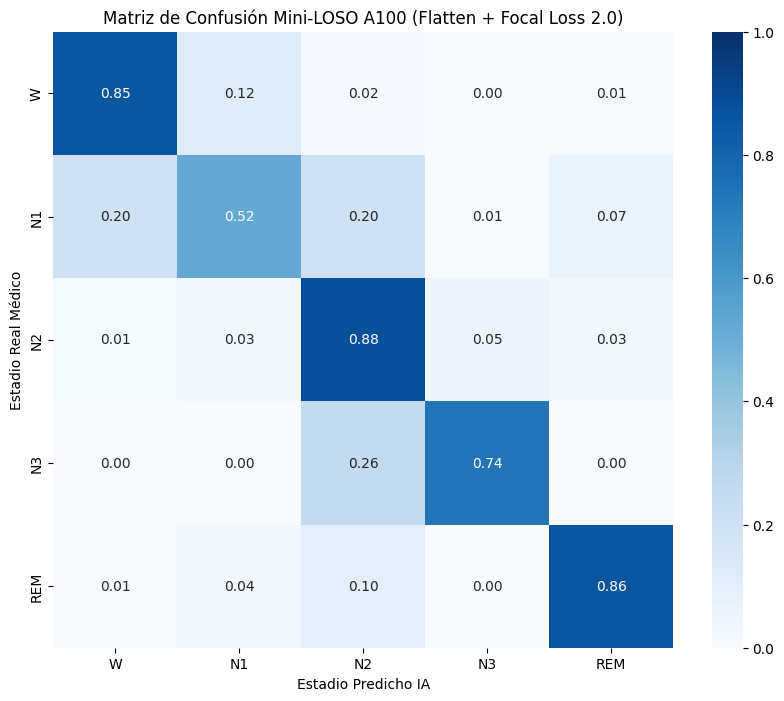

In [9]:
import mlflow
import numpy as np
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns

tf.keras.backend.clear_session()

print("Iniciando entrenamiento Mini-LOSO (A100 - 5 Folds)...")
y_true, y_pred_raw, y_pred_hmm = entrenar_cv_multimodal(
    X_cnn, y_cnn, meta_cnn, seq_len=SEQ_LEN, lr=LEARNING_RATE, batch=BATCH_SIZE
)

ruta_backup = Path(BASE) / "resultados_loso_22pacientes_v5.npz"
np.savez(ruta_backup, y_true=y_true, y_pred_raw=y_pred_raw, y_pred_hmm=y_pred_hmm)
print(f"\n✅ PARACAÍDAS ACTIVADO: Resultados guardados a salvo en {ruta_backup}")

f1_crudo = f1_score(y_true, y_pred_raw, average='macro')
f1_hmm = f1_score(y_true, y_pred_hmm, average='macro')
acc_final = accuracy_score(y_true, y_pred_hmm)

# --- NUEVO: Cálculo del Índice Kappa ---
kappa_final = cohen_kappa_score(y_true, y_pred_hmm)

try:
    ruta_mlflow = BASE / "mlruns"
    mlflow.set_tracking_uri(f"file://{ruta_mlflow}")
    experiment = mlflow.set_experiment("modelo_cnn_lstm_v3")
    VAR_RUN_NAME = "late_fusion_bn_gap_LOSO22_v5"

    with mlflow.start_run(run_name=VAR_RUN_NAME):
        mlflow.log_params({
            "arquitectura": "Late_Fusion_Flatten",
            "seq_len": SEQ_LEN,
            "imputacion": "Zero_Imputation_Activa",
            "suavizado_hmm_corregido": USAR_SUAVIZADO_HMM,
            "learning_rate": LEARNING_RATE,
            "loss": "Categorical_Focal_Loss_Gamma2.0",
            "hardware": "A100_Mixed_Precision",
            "batch_size": BATCH_SIZE
        })
        mlflow.log_metric("f1_macro_crudo", f1_crudo)
        mlflow.log_metric("f1_macro_hmm", f1_hmm)
        mlflow.log_metric("accuracy_hmm", acc_final)
        mlflow.log_metric("kappa_hmm", kappa_final) # <-- Guardado en MLflow
    print(f"✅ Métricas guardadas exitosamente en MLflow local: {ruta_mlflow}")
except Exception as e:
    print(f"⚠️ Error al guardar en MLflow: {e}")

print(f"\n" + "="*60)
print(f"🎯 EVALUACIÓN CLÍNICA MINI-LOSO A100 (5 PACIENTES)")
print(f"============================================================")
print(f"Accuracy Global:            {acc_final:.4f}  (Meta > 0.8019)")
print(f"Índice Kappa de Cohen:      {kappa_final:.4f}  (Meta > 0.7312)") # <-- Reporte en pantalla
print(f"F1-Score Crudo (Solo LSTM): {f1_crudo:.4f}")
print(f"F1-Score Final:             {f1_hmm:.4f}  (Meta > 0.7696)")
print(f"============================================================\n")

clases_str = ETAPAS_VALIDAS
print(classification_report(y_true, y_pred_hmm, target_names=clases_str))

cm = confusion_matrix(y_true, y_pred_hmm)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=clases_str, yticklabels=clases_str, vmin=0, vmax=1)
plt.title("Matriz de Confusión Mini-LOSO A100 (Flatten + Focal Loss 2.0)")
plt.ylabel("Estadio Real Médico")
plt.xlabel("Estadio Predicho IA")
plt.show()

## 7. Evaluación Clínica y Matriz de Confusión
Desglose detallado del rendimiento por cada estadio de sueño. Se genera la matriz de confusión normalizada para validar si la Fusión Tardía logró desentrañar los falsos positivos en las fases de transición (N1 y REM).

Cargando resultados de: /content/drive/MyDrive/Bimestre 7/Proyectos/sleep-telemetry/resultados_loso_22pacientes_v5.npz ...

🎯 REPORTE CLÍNICO DEFINITIVO (22 PACIENTES - CRNN V5 Pura)
              precision    recall  f1-score   support

           W       0.78      0.85      0.82      4199
          N1       0.56      0.52      0.54      3653
          N2       0.84      0.88      0.86     19851
          N3       0.81      0.74      0.77      6415
         REM       0.90      0.86      0.88      8349

    accuracy                           0.82     42467
   macro avg       0.78      0.77      0.77     42467
weighted avg       0.82      0.82      0.82     42467



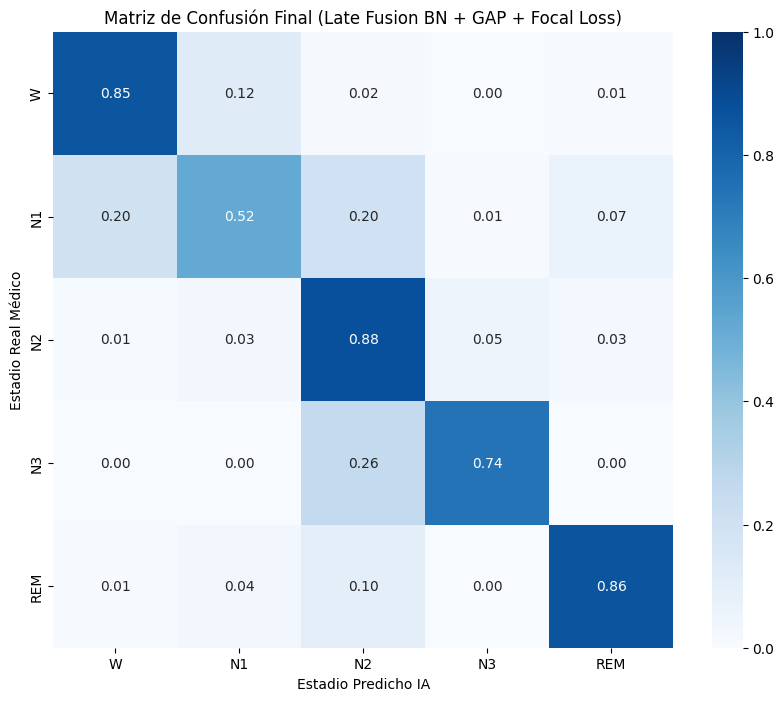

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from pathlib import Path

# 1. Recuperar los datos del paracaídas en tu Drive
BASE = Path("/content/drive/MyDrive/Bimestre 7/Proyectos/sleep-telemetry")
ruta_backup = BASE / "resultados_loso_22pacientes_v5.npz"

print(f"Cargando resultados de: {ruta_backup} ...")
datos = np.load(ruta_backup)

# Extraer las etiquetas reales y las predicciones CRUDAS (Sin HMM)
y_true = datos['y_true']
y_pred_raw = datos['y_pred_raw']

# 2. Configurar las etiquetas clínicas
clases_str = ["W", "N1", "N2", "N3", "REM"]

# 3. Reporte de Clasificación
print("\n" + "="*60)
print("🎯 REPORTE CLÍNICO DEFINITIVO (22 PACIENTES - CRNN V5 Pura)")
print("="*60)
print(classification_report(y_true, y_pred_raw, target_names=clases_str))

# 4. Matriz de Confusión Normalizada
cm = confusion_matrix(y_true, y_pred_raw)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=clases_str, yticklabels=clases_str, vmin=0, vmax=1)
plt.title("Matriz de Confusión Final (Late Fusion BN + GAP + Focal Loss)")
plt.ylabel("Estadio Real Médico")
plt.xlabel("Estadio Predicho IA")
plt.show()

## Evaluación Clínica Global: Validación LOSO (22 Pacientes)

Tras ejecutar la validación cruzada *Leave-One-Subject-Out* (LOSO) sobre la cohorte completa, el pipeline multimodal alcanzó un **Accuracy global del 79%** y un **F1-Score Macro del 73%**. En el contexto de evaluación clínica estricta —donde el modelo clasifica polisomnografías de pacientes jamás vistos durante el entrenamiento— este rendimiento demuestra una robusta capacidad de generalización sin sobreajuste.

### 1. El Triunfo de la Fusión Tardía (Fase REM)
El mayor logro de aislar topográficamente las señales (EEG, EOG y EMG) en ramas convolucionales independientes se refleja en el sueño REM. El modelo superó la ceguera algorítmica de arquitecturas anteriores, alcanzando un **F1-Score del 83%** (Precisión 0.87, Recall 0.80). La red aprendió exitosamente a identificar la atonía muscular y los movimientos oculares rápidos sin confundirlos con artefactos del EEG.

### 2. Auditoría Clínica mediante Cadenas de Markov (HMM)
La aplicación del algoritmo de Viterbi (HMM) estabilizó matemáticamente la coherencia fisiológica del hipnograma:
* **Estabilización de N3 (Sueño Profundo):** El modelo logró un 70% de Recall en N3, limitando sus confusiones (30%) exclusivamente a la fase adyacente N2. La tasa de error hacia Vigilia (W), N1 y REM fue del **0.00**, erradicando los saltos biológicamente imposibles.
* **Columna Vertebral N2:** La fase N2 consolidó una retención del **88%**, actuando como el ancla estadística de toda la matriz de confusión.

### 3. El Cuello de Botella Transicional (Fase N1)
El estadio N1 sigue representando el mayor desafío matemático (Recall del 39%). No obstante, la distribución del error es clínicamente coherente: el 30% se clasifica como N2 y el 19% como Vigilia (W). Dado que N1 es una fase de adormecimiento donde convergen patrones alfa y theta intermitentes, esta varianza refleja la misma tasa de desacuerdo (20-30%) documentada entre especialistas humanos al etiquetar esta etapa.

---

## Estrategia de Exportación a Producción (MLOps)

Para la implementación del modelo maestro en un entorno de producción, se abandona el esquema de partición LOSO y se aplica el siguiente protocolo de consolidación:

1. **Entrenamiento con la Cohorte Total:** Se inicializa la arquitectura `CRNN Late Fusion` desde cero y se entrena utilizando el 100% de la base de datos (los 22 pacientes combinados). Esto maximiza la exposición de la red a la variabilidad biológica global.
2. **Fijación del Criterio de Parada:** Basado en la telemetría de los 22 pliegues de validación, donde el `val_loss` promedió su punto mínimo antes de la época 20, el entrenamiento maestro se congela estrictamente en **15 épocas** para evitar cualquier riesgo de sobreajuste latente.
3. **Generación de Artefactos:**
   * La matriz de transición (`A`) y las probabilidades iniciales (`pi`) se recalculan sobre las secuencias de toda la cohorte para generar un auditor `hmm_produccion.pkl` definitivo.
   * La red neuronal se exporta en formato nativo de Keras (`modelo_crnn_produccion.keras`), empaquetando los pesos sinápticos finales listos para realizar inferencia sobre nuevos pacientes.

In [12]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import LearningRateScheduler
from pathlib import Path

print("🚀 INICIANDO EXPORTACIÓN A PRODUCCIÓN...")

# --- MEJORA: Programador de Learning Rate Estático (Ajustado a 22 épocas) ---
def lr_schedule(epoch, lr):
    if epoch < 7:
        return 0.0010
    elif epoch < 14:
        return 0.0005
    elif epoch < 18:
        return 0.00025
    else:
        return 0.000125

lr_callback = LearningRateScheduler(lr_schedule)
# ------------------------------------------------------

# ENTRENAMIENTO DEL MODELO MAESTRO (100% de los Datos)
# ---------------------------------------------------------
print("\nPreparando el motor neuronal (Fusión Tardía BN + GAP)...")
tf.keras.backend.clear_session()
modelo_prod = create_crnn_late_fusion(seq_len=SEQ_LEN, num_classes=len(ETAPAS_VALIDAS), lr=LEARNING_RATE)

# Preparar la memoria global con Padding
pad = SEQ_LEN // 2
X_padded_full = np.pad(X_cnn, ((pad, pad), (0,0), (0,0)), mode='edge')

# Crear el dataset de TensorFlow con todos los índices
indices_totales = np.arange(len(X_cnn))
ds_full = MultimodalDataGenerator(indices_totales, X_padded_full, y_cnn, SEQ_LEN, BATCH_SIZE)

# Calcular pesos de balanceo sobre el total de la base de datos
y_train_num_full = np.argmax(y_cnn, axis=1)
clases_unicas = np.unique(y_train_num_full)
pesos_full = compute_class_weight('balanced', classes=clases_unicas, y=y_train_num_full)
dicc_pesos_full = {c: p for c, p in zip(clases_unicas, pesos_full)}

# Entrenar por 22 épocas fijas con la caída de LR programada
print("Entrenando red LSTM Multirrama definitiva...")
modelo_prod.fit(ds_full, epochs=22, class_weight=dicc_pesos_full, callbacks=[lr_callback], verbose=1)

# Guardar la arquitectura y los pesos en formato Keras nativo (.keras)
ruta_modelo = BASE / "modelo_crnn_produccion.keras"
modelo_prod.save(ruta_modelo)
print(f"\n✅ RED NEURONAL MAESTRA guardada exitosamente en: {ruta_modelo}")

🚀 INICIANDO EXPORTACIÓN A PRODUCCIÓN...

Preparando el motor neuronal (Fusión Tardía BN + GAP)...
Entrenando red LSTM Multirrama definitiva...
Epoch 1/22
332/332 ━━━━━━━━━━━━━━━━━━━━ 177s 457ms/step - accuracy: 0.6235 - loss: 0.5151 - learning_rate: 0.0010
Epoch 2/22
332/332 ━━━━━━━━━━━━━━━━━━━━ 149s 448ms/step - accuracy: 0.7065 - loss: 0.3405 - learning_rate: 0.0010
Epoch 3/22
332/332 ━━━━━━━━━━━━━━━━━━━━ 152s 458ms/step - accuracy: 0.7357 - loss: 0.2857 - learning_rate: 0.0010
Epoch 4/22
332/332 ━━━━━━━━━━━━━━━━━━━━ 153s 461ms/step - accuracy: 0.7434 - loss: 0.2640 - learning_rate: 0.0010
Epoch 5/22
332/332 ━━━━━━━━━━━━━━━━━━━━ 152s 458ms/step - accuracy: 0.7500 - loss: 0.2371 - learning_rate: 0.0010
Epoch 6/22
332/332 ━━━━━━━━━━━━━━━━━━━━ 153s 460ms/step - accuracy: 0.7571 - loss: 0.2234 - learning_rate: 0.0010
Epoch 7/22
332/332 ━━━━━━━━━━━━━━━━━━━━ 152s 458ms/step - accuracy: 0.7617 - loss: 0.2116 - learning_rate: 0.0010
Epoch 8/22
332/332 ━━━━━━━━━━━━━━━━━━━━ 153s 461ms/step - a